<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Histogram**


Estimated time needed: **45** minutes


In this lab, you will focus on the visualization of data. The dataset will be provided through an RDBMS, and you will need to use SQL queries to extract the required data.


## Objectives


In this lab, you will perform the following:


- Visualize the distribution of data using histograms.

- Visualize relationships between features.

- Explore data composition and comparisons.


## Demo: Working with database


#### Download the database file.


In [1]:
!wget -O survey-data.sqlite https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/QR9YeprUYhOoLafzlLspAw/survey-results-public.sqlite

Resolving cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)... 169.63.118.104
HTTP request sent, awaiting response... 200 OK
Length: 211415040 (202M) [application/octet-stream]
Saving to: ‘survey-data.sqlite’

survey-data.sqlite  100%[===================>] 201.62M  2.92MB/s    in 64s     

2026-08-29 19:18:50 (3.14 MB/s) - ‘survey-data.sqlite’ saved [211415040/211415040]


#### Install the required libraries and import them


In [2]:
!pip install pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.0/11.0 MB 151.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.7/16.7 MB 200.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [pandas]


In [35]:
!pip install matplotlib
!pip install seaborn

In [38]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#### Connect to the SQLite database


In [5]:
conn = sqlite3.connect('survey-data.sqlite')

## Demo: Basic SQL queries

**Demo 1: Count the number of rows in the table**


In [6]:
QUERY = "SELECT COUNT(*) FROM main"
df = pd.read_sql_query(QUERY, conn)
print(df)


   COUNT(*)
0     65437

**Demo 2: List all tables**


In [7]:
QUERY = """
SELECT name as Table_Name 
FROM sqlite_master 
WHERE type = 'table'
"""
pd.read_sql_query(QUERY, conn)


,Table_Name
0,main


**Demo 3: Group data by age**


In [8]:
QUERY = """
SELECT Age, COUNT(*) as count 
FROM main 
GROUP BY Age 
ORDER BY Age
"""
df_age = pd.read_sql_query(QUERY, conn)
print(df_age)


                  Age  count
0     18-24 years old  14098
1     25-34 years old  23911
2     35-44 years old  14942
3     45-54 years old   6249
4     55-64 years old   2575
5   65 years or older    772
6   Prefer not to say    322
7  Under 18 years old   2568

## Hands-on Lab: Visualizing Data with Histograms


### 1. Visualizing the distribution of data (Histograms)


**1.1 Histogram of `CompTotal` (Total Compensation)**


Objective: Plot a histogram of `CompTotal` to visualize the distribution of respondents' total compensation.


In [140]:
# Let's load the assessment requirements columns in a dataframa
df = pd.read_sql_query(
    "SELECT CompTotal, YearsCodePro, Age, TimeSearching, DatabaseWantToWorkWith, RemoteWork, JobSat FROM main",
    conn
)

# Let's inspect the CompTotal column
df["CompTotal"].info()

<class 'pandas.Series'>
RangeIndex: 65437 entries, 0 to 65436
Series name: CompTotal
Non-Null Count  Dtype  
--------------  -----  
33740 non-null  float64
dtypes: float64(1)
memory usage: 511.4 KB

In [145]:
# Let's get same stats about the column
df["CompTotal"].describe()

count     3.374000e+04
mean     2.963841e+145
std      5.444117e+147
min       0.000000e+00
25%       6.000000e+04
50%       1.100000e+05
75%       2.500000e+05
max      1.000000e+150
Name: CompTotal, dtype: float64

In [146]:
# And check for missing values
df["CompTotal"].isna().sum()

np.int64(31697)

In [147]:
# Let's generate a summery for better understanding
# Summarizing findings
summary = pd.DataFrame({
    "Column": df.columns,
    "Data Type": df.dtypes.values,
    "Non-Null Count": df.notnull().sum().values,
    "Missing Values": df.isnull().sum().values,
    "Total rows": df["CompTotal"].count() + df["CompTotal"].isna().sum(),
    "Missing Percentage": (df.isnull().mean() * 100).round(2)
})

summary

,Column,Data Type,Non-Null Count,Missing Values,Total rows,Missing Percentage
CompTotal,CompTotal,float64,33740,31697,65437,48.44
YearsCodePro,YearsCodePro,str,51610,13827,65437,21.13
Age,Age,str,65437,0,65437,0.00
TimeSearching,TimeSearching,str,28911,36526,65437,55.82
DatabaseWantToWorkWith,DatabaseWantToWorkWith,str,42558,22879,65437,34.96
RemoteWork,RemoteWork,str,54806,10631,65437,16.25
JobSat,JobSat,float64,29126,36311,65437,55.49


In [148]:
# Let's remove missing values for Histogram in a new dataframe
comp_total = df["CompTotal"].dropna()
comp_total

72       2040000.0
374        28000.0
379        85000.0
385        50000.0
389       110000.0
           ...    
65396      36000.0
65401      40000.0
65408      61000.0
65412      58000.0
65431      55000.0
Name: CompTotal, Length: 33740, dtype: float64

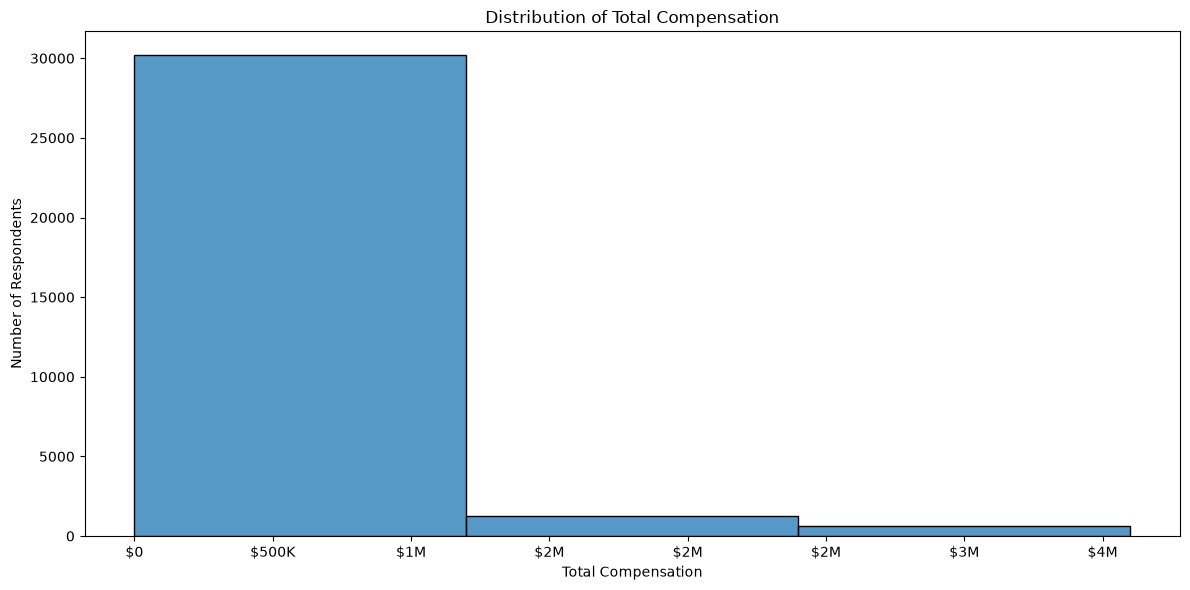

In [149]:
# Plotting histogram
from matplotlib.ticker import FuncFormatter

# Function to format the x labels like 30k 100k 500k 1M 15M values
def currency_formatter(x, pos):
    if x >= 1_000_000:
        return f"${x/1_000_000:.0f}M"
    elif x >= 1_000:
        return f"${x/1_000:.0f}K"
    else:
        return f"${x:.0f}"

# Find the 99th percentile
upper_limit = comp_total.quantile(0.95)

# Data used only for visualization
comp_total_zoom = comp_total[
    comp_total <= upper_limit
]

plt.figure(figsize=(12, 6))

sns.histplot(
    x=comp_total_zoom,
    bins=3,
    stat="count"
)

plt.title("Distribution of Total Compensation")
plt.xlabel("Total Compensation")
plt.ylabel("Number of Respondents")

plt.gca().xaxis.set_major_formatter(
    FuncFormatter(currency_formatter)
)

plt.tight_layout()
plt.show()

**1.2 Histogram of YearsCodePro (Years of Professional Coding Experience)**


Objective: Plot a histogram of `YearsCodePro` to analyze the distribution of coding experience among respondents.


In [150]:
# Let's explore the YearsCodePro column from aur datasset
df["YearsCodePro"].value_counts(dropna=False)

YearsCodePro
NaN                   13827
2                      4168
3                      4093
5                      3526
10                     3251
4                      3215
Less than 1 year       2856
6                      2843
1                      2639
8                      2549
7                      2517
12                     1777
15                     1635
20                     1549
9                      1493
11                     1312
13                     1127
14                     1082
25                      998
16                      946
18                      867
17                      814
30                      689
24                      632
19                      516
22                      492
23                      448
26                      426
27                      380
21                      380
28                      342
35                      285
29                      196
32                      194
40                      194
34     

In [177]:
# Let's convert the column in numerical values
# mapping the non-numerical values
df["YearsCodePro"].replace({
    "Less than 1 year": 0.5,
    "More than 50 years": 51
})

df["YearsCodePro"] = pd.to_numeric(
    df["YearsCodePro"],
    errors="coerce"
)

years_code_pro = df["YearsCodePro"].dropna()

In [178]:
# Let's check the result
years_code_pro.describe()

count    48704.000000
mean        10.739652
std          8.935175
min          1.000000
25%          4.000000
50%          8.000000
75%         15.000000
max         50.000000
Name: YearsCodePro, dtype: float64

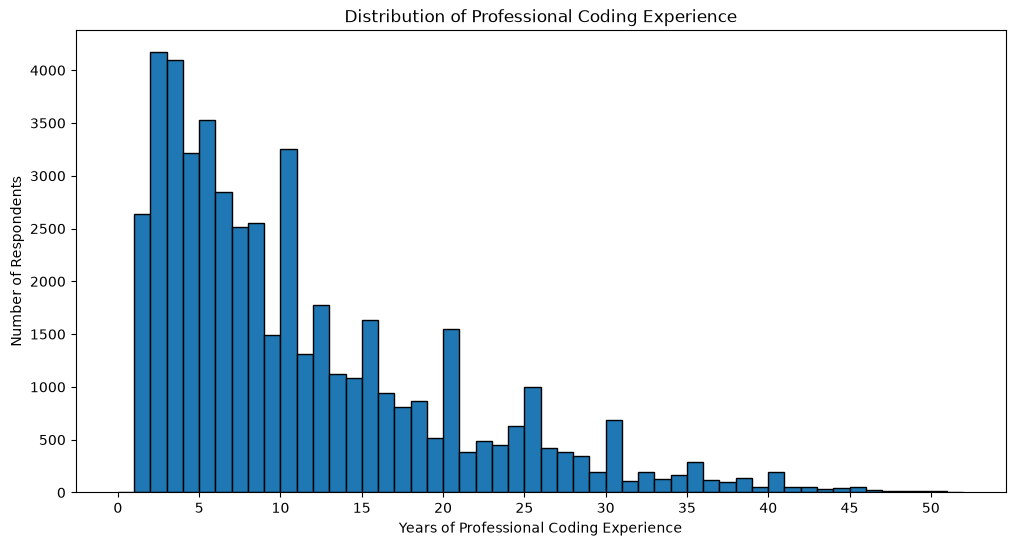

In [179]:
# Now let's plot the histogram for YearsCodePro
plt.figure(figsize=(12, 6))

plt.hist(
    years_code_pro,
    bins=range(0, 53),
    edgecolor="black"
)

plt.title("Distribution of Professional Coding Experience")
plt.xlabel("Years of Professional Coding Experience")
plt.ylabel("Number of Respondents")

plt.xticks(range(0, 53, 5))

plt.show()

### 2. Visualizing Relationships in Data


**2.1 Histogram Comparison of `CompTotal` by `Age` Group**


Objective: Use histograms to compare the distribution of CompTotal across different Age groups.


In [154]:
# Inspecting Age column
df["Age"].value_counts(dropna=False)

Age
25-34 years old       23911
35-44 years old       14942
18-24 years old       14098
45-54 years old        6249
55-64 years old        2575
Under 18 years old     2568
65 years or older       772
Prefer not to say       322
Name: count, dtype: int64

In [155]:
# Let's create a new column for Age to represent the groups
# For example: Under 25
# 25–34
# 35–44
# 45–54
# 55+

# Function to create Age groups
def create_age_group(age):
    if pd.isna(age):
        return None
    elif age == "Under 18 years old":
        return "Under 25"
    elif age == "18-24 years old":
        return "Under 25"
    elif age == "25-34 years old":
        return "25-34"
    elif age == "35-44 years old":
        return "35-44"
    elif age == "45-54 years old":
        return "45-54"
    elif age == "55-64 years old":
        return "55+"
    elif age == "65 years or older":
        return "55+"
    else:
        return None

# Converting and checking the new group column
df["AgeGroup"] = df["Age"].apply(create_age_group)
df["AgeGroup"].value_counts()

AgeGroup
25-34       23911
Under 25    16666
35-44       14942
45-54        6249
55+          3347
Name: count, dtype: int64

In [156]:
# For this histogram we just need repondents who have both values
plot_df = df.dropna(
    subset=["CompTotal", "AgeGroup"]
)

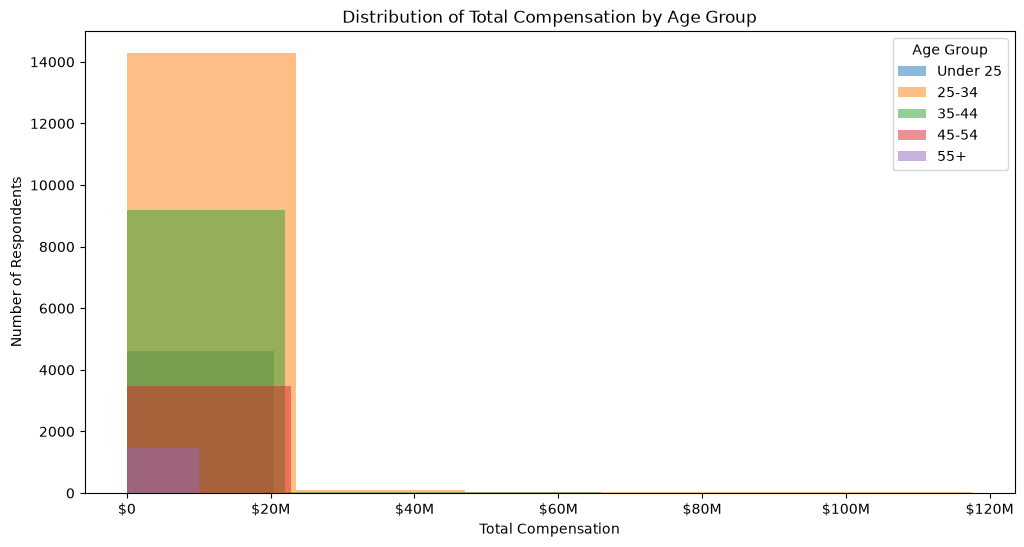

In [157]:
# Creating a histogram comparison
upper_limit = plot_df["CompTotal"].quantile(0.99)

plt.figure(figsize=(12, 6))

age_groups = [
    "Under 25",
    "25-34",
    "35-44",
    "45-54",
    "55+"
]

for age_group in age_groups:
    data = plot_df.loc[
        plot_df["AgeGroup"] == age_group,
        "CompTotal"
    ]

    data = data[data <= upper_limit]

    plt.hist(
        data,
        bins=5,
        alpha=0.5,
        label=age_group
    )

plt.title("Distribution of Total Compensation by Age Group")
plt.xlabel("Total Compensation")
plt.ylabel("Number of Respondents")

plt.gca().xaxis.set_major_formatter(
    FuncFormatter(currency_formatter)
)

plt.legend(title="Age Group")

plt.show()

**2.2 Histogram of TimeSearching for Different Age Groups**


Objective: Use histograms to explore the distribution of `TimeSearching` (time spent searching for information) for respondents across different age groups.


In [158]:
# Inspecting TimeSearching
df["TimeSearching"].value_counts(dropna=False)

TimeSearching
NaN                           36526
30-60 minutes a day           10951
15-30 minutes a day            7805
60-120 minutes a day           5275
Less than 15 minutes a day     2689
Over 120 minutes a day         2191
Name: count, dtype: int64

In [159]:
# Let's create a new column for TimeSearching to represent the groups in minutes
time_mapping = {
    "Less than 15 minutes a day": 7.5,
    "15-30 minutes a day": 22.5,
    "30-60 minutes a day": 45,
    "60-120 minutes a day": 90,
    "Over 120 minutes a day": 150
}

df["TimeSearchingMinutes"] = df["TimeSearching"].map(time_mapping)

In [160]:
# Checking the new column
df["TimeSearchingMinutes"].describe()

count    28911.000000
mean        51.605790
std         37.800457
min          7.500000
25%         22.500000
50%         45.000000
75%         90.000000
max        150.000000
Name: TimeSearchingMinutes, dtype: float64

In [161]:
# Let's check the cross validation between the TimeSearching columns
pd.crosstab(
    df["TimeSearching"],
    df["TimeSearchingMinutes"]
)

TimeSearchingMinutes,7.5,22.5,45.0,90.0,150.0
TimeSearching,,,,,
15-30 minutes a day,0,7805,0,0,0
30-60 minutes a day,0,0,10951,0,0
60-120 minutes a day,0,0,0,5275,0
Less than 15 minutes a day,2689,0,0,0,0
Over 120 minutes a day,0,0,0,0,2191


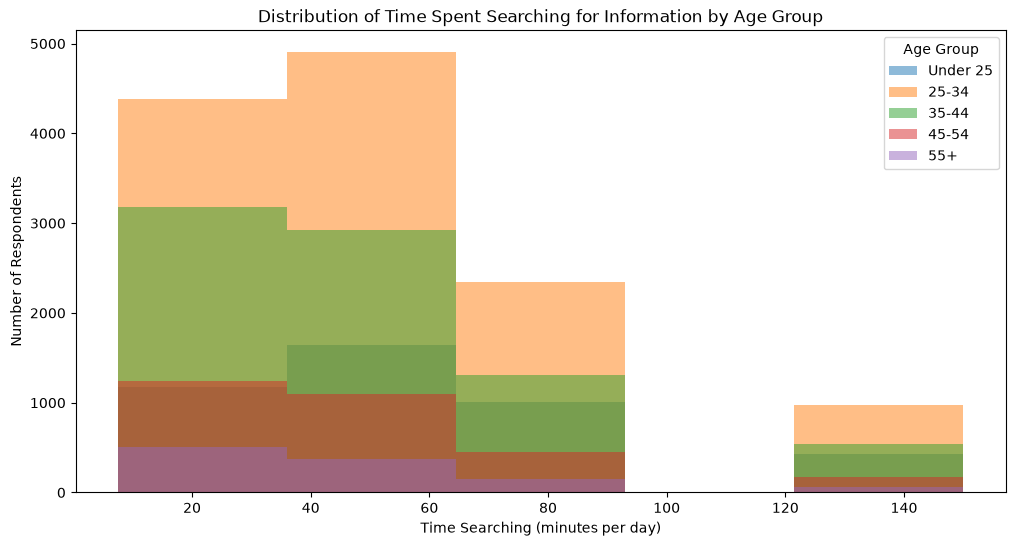

In [162]:
# Now we are ready to plot our histogram
plot_df = df.dropna(
    subset=["TimeSearchingMinutes", "AgeGroup"]
)

age_groups = [
    "Under 25",
    "25-34",
    "35-44",
    "45-54",
    "55+"
]

plt.figure(figsize=(12, 6))

for age_group in age_groups:
    data = plot_df.loc[
        plot_df["AgeGroup"] == age_group,
        "TimeSearchingMinutes"
    ]

    plt.hist(
        data,
        bins=5,
        alpha=0.5,
        label=age_group
    )

plt.title("Distribution of Time Spent Searching for Information by Age Group")
plt.xlabel("Time Searching (minutes per day)")
plt.ylabel("Number of Respondents")
plt.legend(title="Age Group")

plt.show()

### 3. Visualizing the Composition of Data


**3.1 Histogram of Most Desired Databases (`DatabaseWantToWorkWith`)**


Objective: Visualize the most desired databases for future learning using a histogram of the top 5 databases.


In [163]:
# Inspecting the column
df["DatabaseWantToWorkWith"].value_counts(dropna=False).head(10)

DatabaseWantToWorkWith
NaN                     22879
PostgreSQL               3738
PostgreSQL;SQLite        1533
SQLite                   1476
Microsoft SQL Server     1431
MySQL                    1139
MongoDB                   917
PostgreSQL;Redis          855
MongoDB;PostgreSQL        600
MySQL;PostgreSQL          504
Name: count, dtype: int64

In [164]:
# Let's split the multiple databases selecting into unique counts
database_counts = (
    df["DatabaseWantToWorkWith"]
    .dropna()
    .str.split(";")
    .explode()
    .str.strip()
    .value_counts()
)
database_counts.head(10)

DatabaseWantToWorkWith
PostgreSQL              24005
SQLite                  13489
MySQL                   12269
MongoDB                 10982
Redis                   10847
Microsoft SQL Server     7905
Elasticsearch            6246
MariaDB                  5947
Dynamodb                 3503
Supabase                 2930
Name: count, dtype: int64

In [165]:
# Let's work on the top 8 databases respondents want to work with
top_8_databases = database_counts.head(8)

top_8_databases

DatabaseWantToWorkWith
PostgreSQL              24005
SQLite                  13489
MySQL                   12269
MongoDB                 10982
Redis                   10847
Microsoft SQL Server     7905
Elasticsearch            6246
MariaDB                  5947
Name: count, dtype: int64

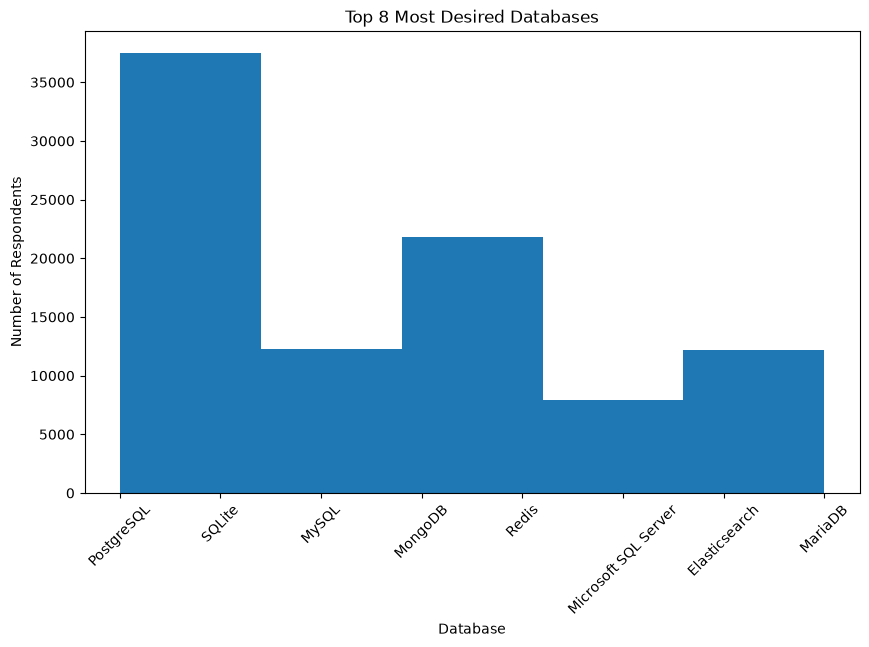

In [166]:
# Now let's generate our histogram
plt.figure(figsize=(10, 6))

plt.hist(
    top_8_databases.index,
    bins=5,
    weights=top_8_databases.values
)

plt.title("Top 8 Most Desired Databases")
plt.xlabel("Database")
plt.ylabel("Number of Respondents")

plt.xticks(rotation=45)
plt.show()

**3.2 Histogram of Preferred Work Locations (`RemoteWork`)**


Objective: Use a histogram to explore the distribution of preferred work arrangements (`remote work`).


In [167]:
# Inspecting RemoteWork column
df["RemoteWork"].value_counts(dropna=False)

RemoteWork
Hybrid (some remote, some in-person)    23015
Remote                                  20831
In-person                               10960
NaN                                     10631
Name: count, dtype: int64

In [168]:
# Excluding missing values for histogram
remote_work_counts = (
    df["RemoteWork"]
    .dropna()
    .value_counts()
)

remote_work_counts

RemoteWork
Hybrid (some remote, some in-person)    23015
Remote                                  20831
In-person                               10960
Name: count, dtype: int64

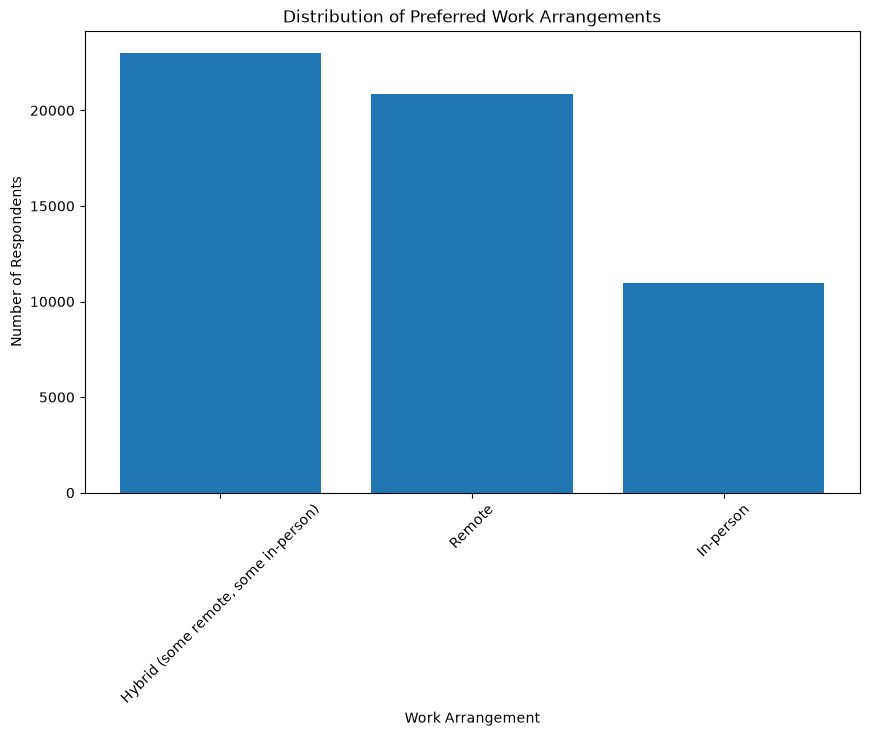

In [169]:
# Visualizing histogram chart 
plt.figure(figsize=(10, 6))

plt.bar(
    remote_work_counts.index,
    remote_work_counts.values
)

plt.title("Distribution of Preferred Work Arrangements")
plt.xlabel("Work Arrangement")
plt.ylabel("Number of Respondents")

plt.xticks(rotation=45)
plt.show()

### 4. Visualizing Comparison of Data


**4.1 Histogram of Median CompTotal for Ages 45 to 60**


Objective: Plot the histogram for `CompTotal` within the age group 45 to 60 to analyze compensation distribution among mid-career respondents.


In [170]:
# Filtering the AgeGroup
age_45_54 = df[
    df["AgeGroup"] == "45-54"
].copy()

# Checking compensation for the group
age_45_54["CompTotal"]

2            NaN
8            NaN
11           NaN
15           NaN
22           NaN
          ...   
65323        NaN
65332        NaN
65348        NaN
65378        NaN
65431    55000.0
Name: CompTotal, Length: 6249, dtype: float64

In [171]:
# Let's remove missing values rows for the group
age_45_54 = age_45_54.dropna(
    subset=["CompTotal"]
)

age_45_54["CompTotal"].describe()

count    3.516000e+03
mean     5.076824e+06
std      1.720098e+08
min      0.000000e+00
25%      7.730000e+04
50%      1.300000e+05
75%      2.200000e+05
max      1.000000e+10
Name: CompTotal, dtype: float64

In [172]:
# Let's calculate the median of total compensation
median_comp_total = age_45_54["CompTotal"].median()
print(f"Median CompTotal: ${median_comp_total:,.2f}")

Median CompTotal: $130,000.00

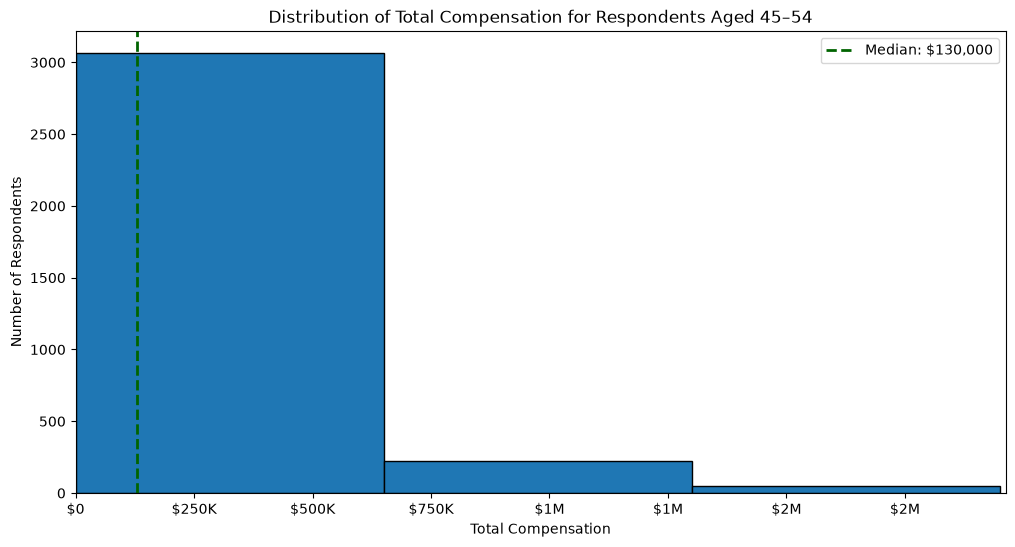

In [173]:
# Let's visualize our histogram
upper_limit = age_45_54["CompTotal"].quantile(0.95)

plt.figure(figsize=(12, 6))

plt.hist(
    age_45_54.loc[
        age_45_54["CompTotal"] <= upper_limit,
        "CompTotal"
    ],
    bins=3,
    edgecolor="black"
)

plt.axvline(
    median_comp_total,
    color="darkgreen",
    linestyle="--",   
    linewidth=2,
    label=f"Median: ${median_comp_total:,.0f}"
)

plt.xlim(0, upper_limit)

plt.title("Distribution of Total Compensation for Respondents Aged 45–54")
plt.xlabel("Total Compensation")
plt.ylabel("Number of Respondents")

plt.gca().xaxis.set_major_formatter(
    FuncFormatter(currency_formatter)
)

plt.legend()

plt.show()

**4.2 Histogram of Job Satisfaction (`JobSat`) by YearsCodePro**


Objective: Plot the histogram for `JobSat` scores based on respondents' years of professional coding experience.


In [180]:
# Inspecting JobSat column
df["JobSat"].value_counts(dropna=False)

JobSat
NaN     36311
8.0      7509
7.0      6379
6.0      3751
9.0      3626
10.0     2251
5.0      1956
3.0      1165
4.0      1130
2.0       772
0.0       311
1.0       276
Name: count, dtype: int64

In [181]:
# Let's check our YearCodePro again
df["YearsCodePro"].value_counts(dropna=False)

YearsCodePro
NaN     16733
2.0      4168
3.0      4093
5.0      3526
10.0     3251
4.0      3215
6.0      2843
1.0      2639
8.0      2549
7.0      2517
12.0     1777
15.0     1635
20.0     1549
9.0      1493
11.0     1312
13.0     1127
14.0     1082
25.0      998
16.0      946
18.0      867
17.0      814
30.0      689
24.0      632
19.0      516
22.0      492
23.0      448
26.0      426
27.0      380
21.0      380
28.0      342
35.0      285
29.0      196
32.0      194
40.0      194
34.0      169
38.0      134
33.0      132
36.0      119
31.0      106
37.0      104
45.0       56
42.0       55
39.0       54
41.0       51
44.0       42
43.0       37
46.0       21
50.0       14
48.0       14
49.0       11
47.0       10
Name: count, dtype: int64

In [186]:
# Let's create experience groups for the visualization
bins = [0, 5, 10, 20, 30, 50, float("inf")]

labels = [
    "0–5 years",
    "6–10 years",
    "11–20 years",
    "21–30 years",
    "31–50 years",
    "50+ years"
]

df["ExperienceGroup"] = pd.cut(
    df["YearsCodePro"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

df["ExperienceGroup"].value_counts().sort_index()

ExperienceGroup
0–5 years      17641
6–10 years     12653
11–20 years    11625
21–30 years     4983
31–50 years     1802
50+ years          0
Name: count, dtype: int64

In [187]:
# Let's create a new dataframe without missing values
plot_df = df.dropna(
    subset=["JobSat", "ExperienceGroup"]
)

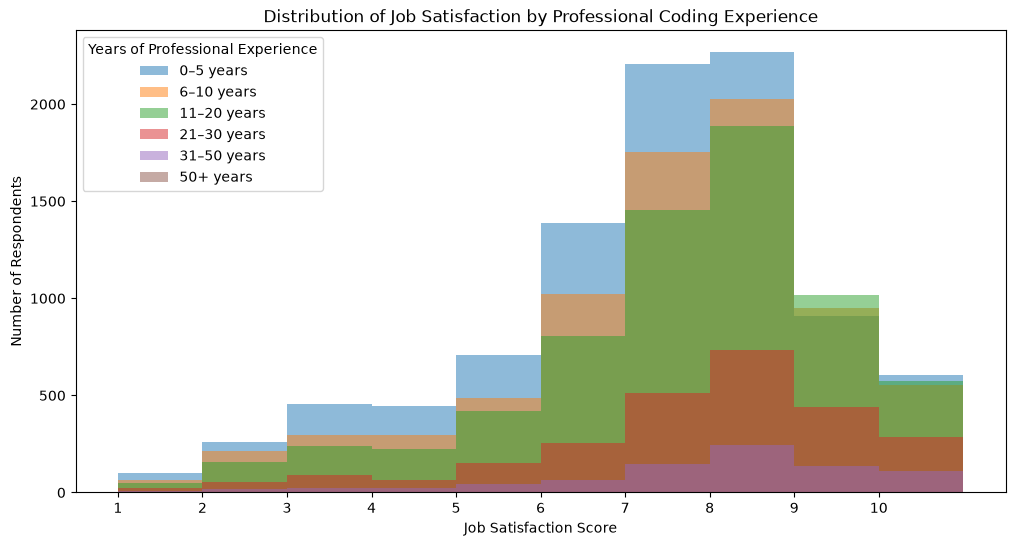

In [188]:
# Let's visualize our histogram
plt.figure(figsize=(12, 6))

experience_groups = [
    "0–5 years",
    "6–10 years",
    "11–20 years",
    "21–30 years",
    "31–50 years",
    "50+ years"
]

for group in experience_groups:
    data = plot_df.loc[
        plot_df["ExperienceGroup"] == group,
        "JobSat"
    ]

    plt.hist(
        data,
        bins=range(1, 12),
        alpha=0.5,
        label=group
    )

plt.title("Distribution of Job Satisfaction by Professional Coding Experience")
plt.xlabel("Job Satisfaction Score")
plt.ylabel("Number of Respondents")

plt.xticks(range(1, 11))
plt.legend(title="Years of Professional Experience")

plt.show()

### Final step: Close the database connection


Once you've completed the lab, make sure to close the connection to the SQLite database:



In [189]:
conn.close()

### Summary


In this lab, you used histograms to visualize various aspects of the dataset, focusing on:

- Distribution of compensation, coding experience, and work hours.

- Relationships in compensation across age groups and work status.

- Composition of data by desired databases and work environments.

- Comparisons of job satisfaction across years of experience.

Histograms helped reveal patterns and distributions in the data, enhancing your understanding of developer demographics and preferences.


## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


Copyright © IBM Corporation. All rights reserved.
